# Klein Filters

In the paper [Topological Convolutional Layers for Deep Learning](https://www.jmlr.org/papers/volume24/21-0073/21-0073.pdf#10) Love et al define a function $F_K$ that maps Klein bottle into the space of quadratic functions on $[-1,1]^2$. This map is given by 

$$
\begin{align*}
F_K(\theta_1, \theta_2)(x,y) &= \sin(\theta_2)\left( \cos(\theta_1)x + \sin(\theta_1)y \right)
+ \cos(\theta_2) Q\left( \cos(\theta_1)x + \sin(\theta_1)y \right) = \\
&= \begin{bmatrix} \sin(\theta_2) & \cos(\theta_2) \end{bmatrix} \begin{bmatrix} t \\ Q(t) \end{bmatrix}
\end{align*}
$$

where $t = \cos(\theta_1)x + \sin(\theta_1)y = (x,y)\cdot\left( \cos \theta_1, \sin \theta_1 \right)$ and $Q$ is the degree-2 Chebyshev polynomial defined as 

$$
Q(t) = 2t^2 - 1.
$$

As given, $F_K$ is a function on **2-dimensional torus** $S^1\times S^1$, parametrized by angles $\theta_1$ and $\theta_2$ correspondingly. However it is straightforward to see that $F_K$ satisfies the following properties:
1. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + 2\pi k, \theta_2 + 2\pi l)$,
2. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + \pi, -\theta_2)$.

Therefore it actually defines a function on a **Klein bottle** $K$.

In [1]:
import numpy as np
from scipy.integrate import dblquad
from scipy.stats.qmc import Sobol
from sklearn.metrics import pairwise_distances

from ripser import ripser  # Comment if run on Kaggle server
from persim import plot_diagrams # Comment if run on Kaggle server

from collections import defaultdict

import plotly.graph_objs as go
import matplotlib.pyplot as plt

from typing import Callable


In [2]:
def projection_onto_a_line(theta: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Creates a function that projects a point onto a line.
    """
    return lambda x,y: (x * np.cos(theta) + y * np.sin(theta))
    

def chebyshev_2(t: float) -> float:
    """
    Chebyshev polynomial of the 2nd degree.
    """
    return 2 * t**2 - 1


def klein_filter(theta_1: float, theta_2: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Klein filter for given angles theta_1 and theta_2.
    """
    t = projection_onto_a_line(theta_1)
    return lambda x,y: np.sin(theta_2) * t(x,y) + np.cos(theta_2) * chebyshev_2(t(x,y))

In [3]:
def generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True) -> np.ndarray:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Parameters:
    - theta_1: Angle for the first projection.
    - theta_2: Angle for the second projection.
    - size: Size of the matrix.
    - midpoint: If True, use midpoints for the grid; otherwise, use edges.
    """
    f = klein_filter(theta_1, theta_2)
    coords = np.linspace(-1 + 1/size, 1 - 1/size, size) if midpoint else np.linspace(-1, 1, size)
    X, Y = np.meshgrid(coords, coords)
    Z = f(X, Y)
    return Z

def generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3) -> np.ndarray:
    """
    Generate a Klein filter matrix of given size for specified angles using integration.
    """
    f = klein_filter(theta_1, theta_2)
    result = np.zeros([size, size])
    for x in range(size):
        for y in range(size):
            xmin = -1.0 + ((2 * x) / (2 * size))
            xmax = -1.0 + ((2 * (x + 1.0)) / (2 * size))
            ymin = -1.0 + ((2 * y) / (2 * size))
            ymax = -1.0 + ((2 * (y + 1.0)) / (2 * size))

            Filter = dblquad(f, xmin, xmax, ymin, ymax)[0]
            result[y][x] = Filter

    return result

In [4]:
generate_klein_filter_matrix(0, np.pi)

array([[0.11111111, 1.        , 0.11111111],
       [0.11111111, 1.        , 0.11111111],
       [0.11111111, 1.        , 0.11111111]])

In [ ]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(10, 10))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = 2 * np.pi * i / n
        theta_2 = 2 * np.pi * j / n
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        #filter_img = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        #axes[i, j].set_title(f"$\\theta_1$={theta_1:.2f}\t$\\theta_2$={theta_2:.2f}", fontsize=6)
        # Draw black border
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

fig.tight_layout()

fig.savefig('Grid-of-filters.png', dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'plt' is not defined

Notice that the $F_K$ indeed satsfies the properties: the filters in the bottom are sort of "mirrored" from the filters from above: this is an illustration of the second property, and the first row/column coincides with the last row/column - the first property in action.

## Persistent Homology of Filters
Let's flatten these images and check the homology of the point cloud in $\R^9$ we will get. Ideally we will get the homology of Klein bottle:
$$
H_i(K;\Z) = 
\begin{cases}
\Z, \text{ if } i=0 \\
\Z \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

`ripser` allows us to compute the homology over the finite field. We will do it over $\Z/2$ and $\Z/3$, since, using UCT:

$$
H_i(K;\Z/2) = 
\begin{cases}
\Z/2, \text{ if } i=0 \\
\Z/2 \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

But

$$
H_i(K;\Z/3) = 
\begin{cases}
\Z/3, \text{ if } i=0,1 \\
0, \text{ otherwise.}
\end{cases}
$$


Let $\theta_1$ runs up to $\pi$.
So we should get the homology of the Klein bottle as above

In [11]:
n_angles = 5_00

th1s = np.random.uniform(0, np.pi, n_angles)
th2s = np.random.uniform(0, 2*np.pi, n_angles)

In [12]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
    #klein_filter_matrix = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(500, 9)

In [13]:
%%time

diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

CPU times: user 16.7 s, sys: 2.1 s, total: 18.8 s
Wall time: 15.9 s


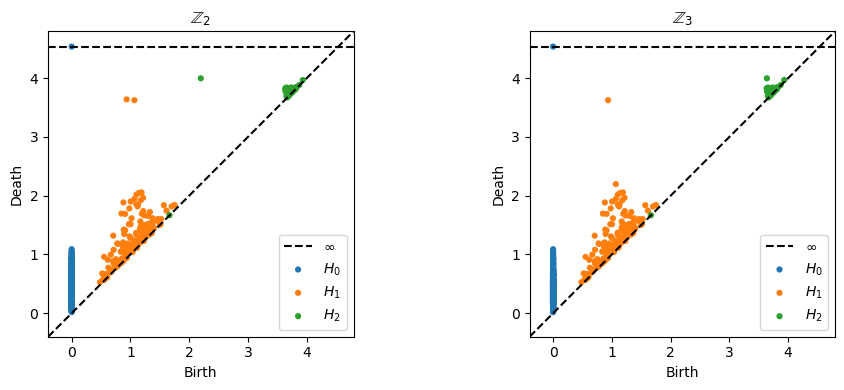

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [15]:
from matplotlib.patches import Circle

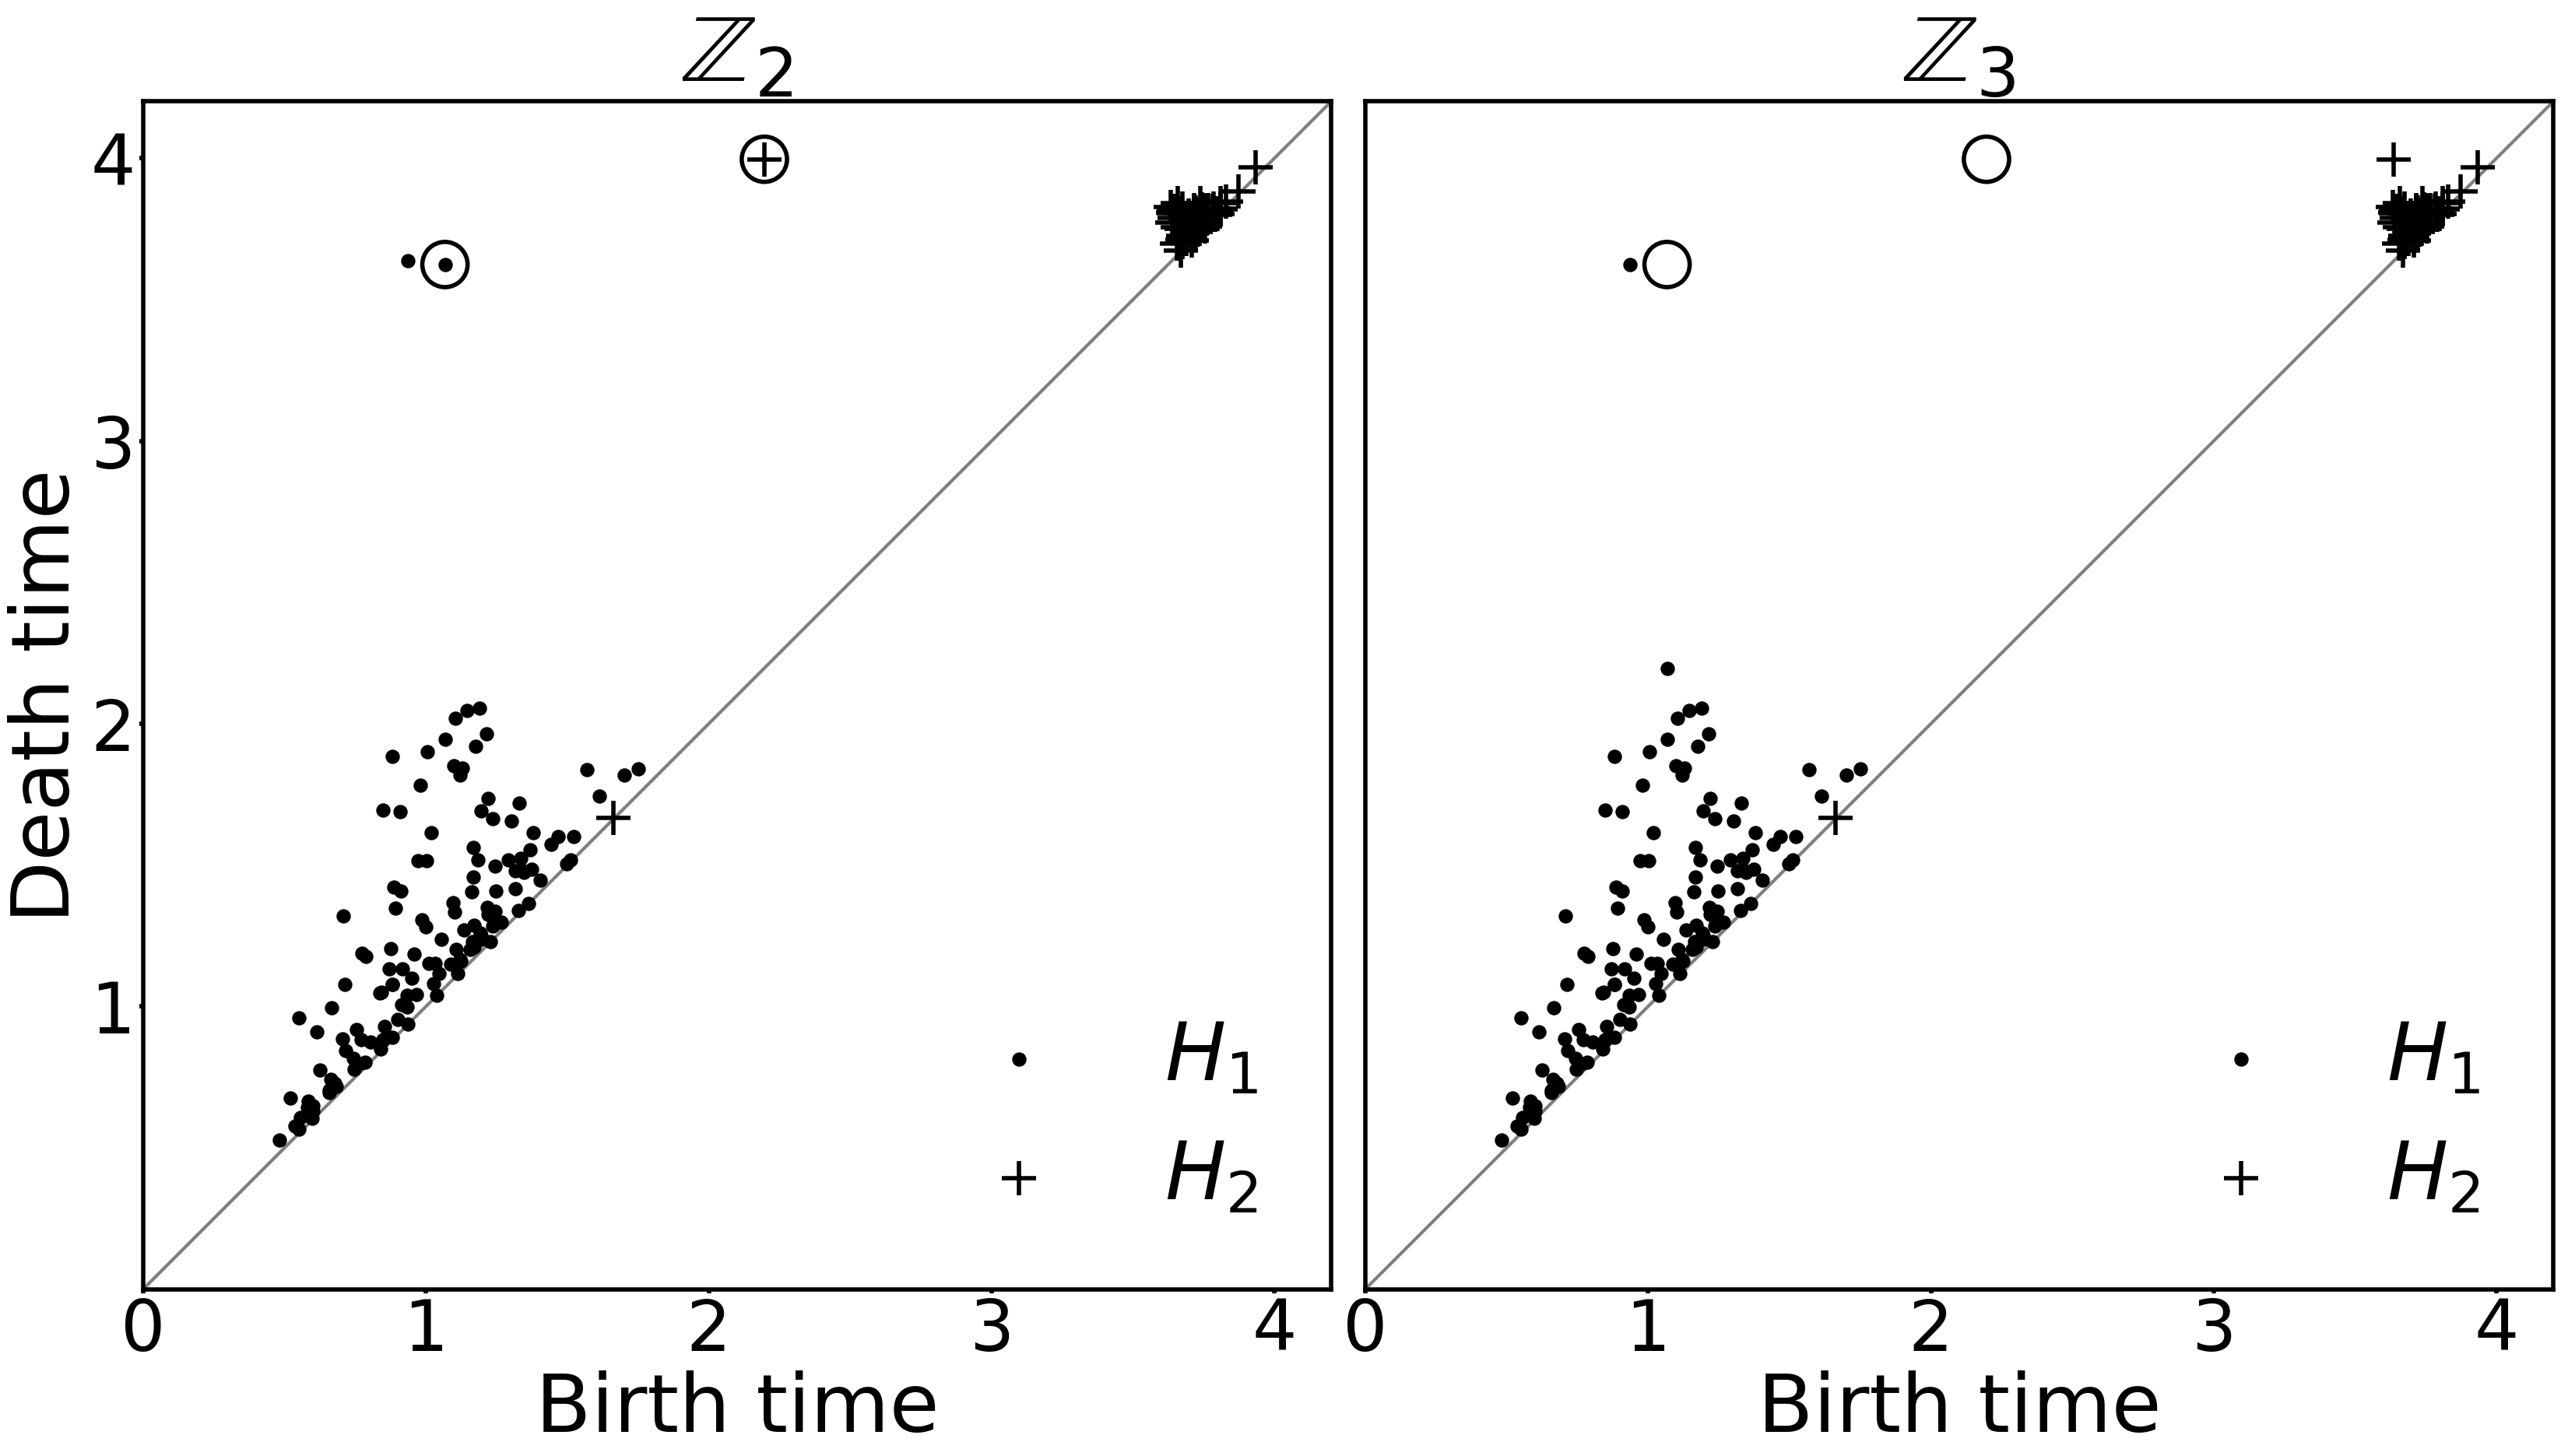

In [98]:
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(33, 20))

dot_size = 600
square_size = 1000
circle_radius = 0.08
large_font_size = 75
small_font_size = 65
subtitle_font_size = 90

#fig.subplots_adjust(bottom=0.01, right=0.02, top=0.02, left=0.01)

#fig.suptitle('Horizontally stacked subplots')

#ax2.scatter(diagrams2[0][:,0], diagrams2[0][:,1], marker = "_", color='black')
ax2.scatter(diagrams2[1][:,0], diagrams2[1][:,1], marker = ".", 
            color='black', alpha=1, s=dot_size, label='$H_1$')
ax2.scatter(diagrams2[2][:,0], diagrams2[2][:,1], marker = "+",linewidths=4,
            color='black', alpha=1, s=square_size, label='$H_2$')
ax2.set_xticks([0,1,2,3,4])
ax2.tick_params(axis='both', which='major', labelsize=small_font_size)
ax2.set_xlabel('Birth time', fontsize=large_font_size)
ax2.set_yticks([1,2,3,4])
ax2.set_ylabel('Death time', fontsize=large_font_size)
ax2.plot(np.linspace(0,4.2,100), np.linspace(0,4.2,100), color='black', alpha=0.5, linewidth=3)
ax2.set_aspect(1)
ax2.legend(loc='lower right', prop={'size': large_font_size}, frameon=False)
ax2.set_title('$\mathbb{Z}_2$', fontsize=subtitle_font_size)

ax2.set_xlim((0,4.2))
ax2.set_ylim((0,4.2))

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(4)

# increase tick width
ax2.tick_params(width=4)

lifetimes22 = diagrams2[2][:,1]-diagrams2[2][:,0]
ax2.add_patch(Circle((diagrams2[2][np.argsort(lifetimes22)[-1],0], 
              diagrams2[2][np.argsort(lifetimes22)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))



lifetimes21 = diagrams2[1][:,1]-diagrams2[1][:,0]
ax2.add_patch(Circle((diagrams2[1][np.argsort(lifetimes21)[-2],0], 
              diagrams2[1][np.argsort(lifetimes21)[-2],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))




#ax3.scatter(diagrams3[0][:,0], diagrams3[0][:,1])
ax3.scatter(diagrams3[1][:,0], diagrams3[1][:,1], marker = ".", 
            color='black', alpha=1, s=dot_size, label='$H_1$')
ax3.scatter(diagrams3[2][:,0], diagrams3[2][:,1], marker = "+",linewidths=4, 
            color='black', alpha=1, s=square_size, label='$H_2$')
ax3.set_xlabel('Birth time', fontsize=large_font_size)
ax3.tick_params(axis='both', which='major', labelsize=small_font_size)
ax3.plot(np.linspace(0,4.2,100), np.linspace(0,4.2,100), color='black', alpha=0.5, linewidth=3)
ax3.set_xticks([0,1,2,3,4])
ax3.set_yticks([])
ax3.set_aspect(1)
ax3.legend(loc='lower right', prop={'size': large_font_size}, frameon=False)
ax3.set_title('$\mathbb{Z}_3$', fontsize=subtitle_font_size)

#lifetimes32 = diagrams3[2][:,1]-diagrams3[2][:,0]


ax3.add_patch(Circle((diagrams2[2][np.argsort(lifetimes22)[-1],0], 
              diagrams2[2][np.argsort(lifetimes22)[-1],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))

#lifetimes32 = diagrams3[1][:,1]-diagrams3[1][:,0]


ax3.add_patch(Circle((diagrams2[1][np.argsort(lifetimes21)[-2],0], 
              diagrams2[1][np.argsort(lifetimes21)[-2],1]),
             radius=circle_radius, edgecolor='black', fill=False, linewidth=4))

ax3.set_xlim((0,4.2))
ax3.set_ylim((0,4.2))

for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(4)

# increase tick width
ax3.tick_params(width=4)



fig.tight_layout()

#fig.show()

fig.savefig('Gabor-filters-Klein-homology.png', dpi=300, bbox_inches='tight')

<>:10: SyntaxWarning:

invalid escape sequence '\m'

<>:64: SyntaxWarning:

invalid escape sequence '\m'

<>:65: SyntaxWarning:

invalid escape sequence '\m'

<>:10: SyntaxWarning:

invalid escape sequence '\m'

<>:64: SyntaxWarning:

invalid escape sequence '\m'

<>:65: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_19687/3487175863.py:10: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_19687/3487175863.py:64: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_19687/3487175863.py:65: SyntaxWarning:

invalid escape sequence '\m'



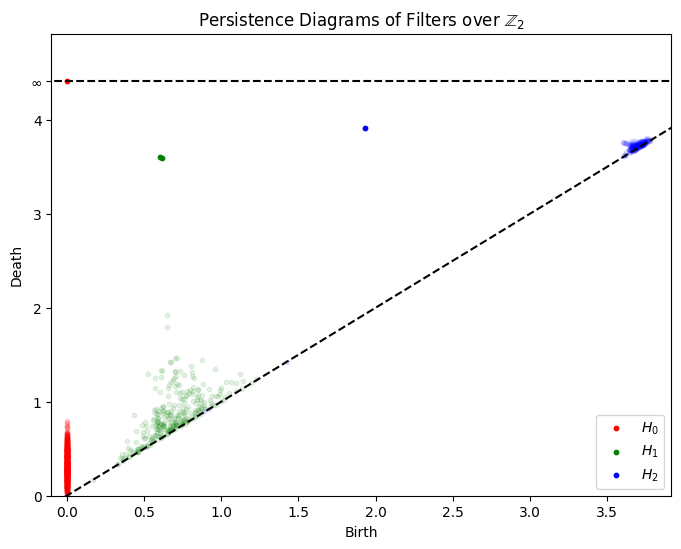

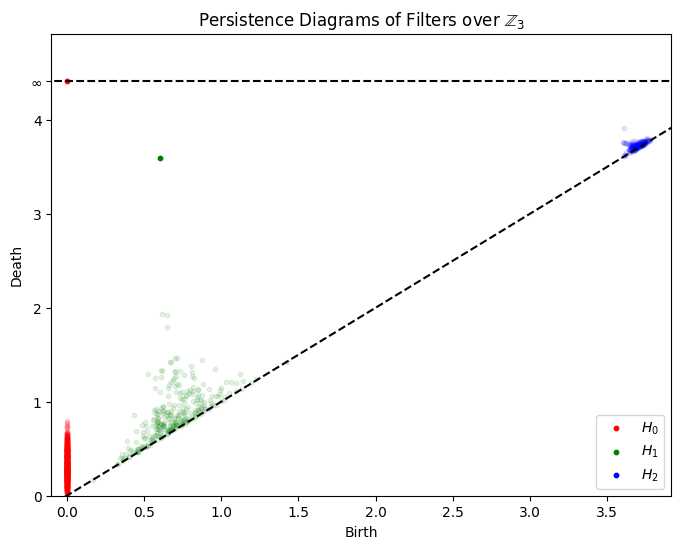

In [134]:
import plotly.graph_objects as go

COLOR_PER_DIM = {
    0: 'red',  # Red for dimension 0
    1: 'green',  # Green for dimension 1
    2: 'blue',  # Blue for dimension 2
}


def matplotlib_diagrams(diagrams, ax=None, size=50, threshold=1.5, field="$\mathbb{Z}_2$"):
    """
    Plot persistence diagrams using Matplotlib.

    Parameters:
    - diagrams: List of persistence diagrams.
    - ax: Matplotlib Axes to plot on (optional).
    - size: Size of the points in the plot.
    - threshold: Birth–death difference below which points are 'non-relevant'.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # remove points with infinite death in H0
    d0 = diagrams[0]
    mask_inf = ~np.isinf(d0[:, 1])
    diagrams[0] = d0[mask_inf]

    max_val = max(np.max(d[:, 1]) for d in diagrams if len(d) > 0)
    inf_tick = max_val + 0.5


    # diagonal and infinity lines
    ax.plot([-0.5, max_val], [-0.5, max_val], 'k--')
    ax.plot([-0.5, max_val], [inf_tick,inf_tick], 'k--')
    ax.scatter([0], [inf_tick], c=COLOR_PER_DIM[0], s=size)

    # scatter by dimension
    for dim, diagram in enumerate(diagrams):
        if len(diagram) == 0:
            continue
        births = diagram[:, 0]
        deaths = diagram[:, 1]
        rel = (deaths - births) >= threshold
        nr = ~rel

        ax.scatter(births[nr], deaths[nr],
                   s=size, c=COLOR_PER_DIM[dim], alpha=0.1)
        ax.scatter(births[rel], deaths[rel],
                   s=size, c=COLOR_PER_DIM[dim], alpha=1.0,
                   label=f'$H_{dim}$')

    ax.set_title(f'Persistence Diagrams of Filters over {field}')
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    base_ticks = np.arange(0, int(np.ceil(max_val)) + 1, 1)
    ax.set_yticks(np.concatenate([base_ticks, [inf_tick]]))
    ax.set_yticklabels([str(int(t)) for t in base_ticks] + [r'$\infty$'])
    ax.set_xlim(-0.1, max_val)
    ax.set_ylim(0, max_val + 1)
    ax.legend(loc='best')
    return ax
    
# Plot the persistence diagrams
pd_2 = matplotlib_diagrams(diagrams2, size=10, field="$\mathbb{Z}_2$")
pd_3 = matplotlib_diagrams(diagrams3, size=10, field="$\mathbb{Z}_3$")


<>:3: SyntaxWarning:

invalid escape sequence '\m'

<>:6: SyntaxWarning:

invalid escape sequence '\m'

<>:3: SyntaxWarning:

invalid escape sequence '\m'

<>:6: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_19687/3935299713.py:3: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_19687/3935299713.py:6: SyntaxWarning:

invalid escape sequence '\m'



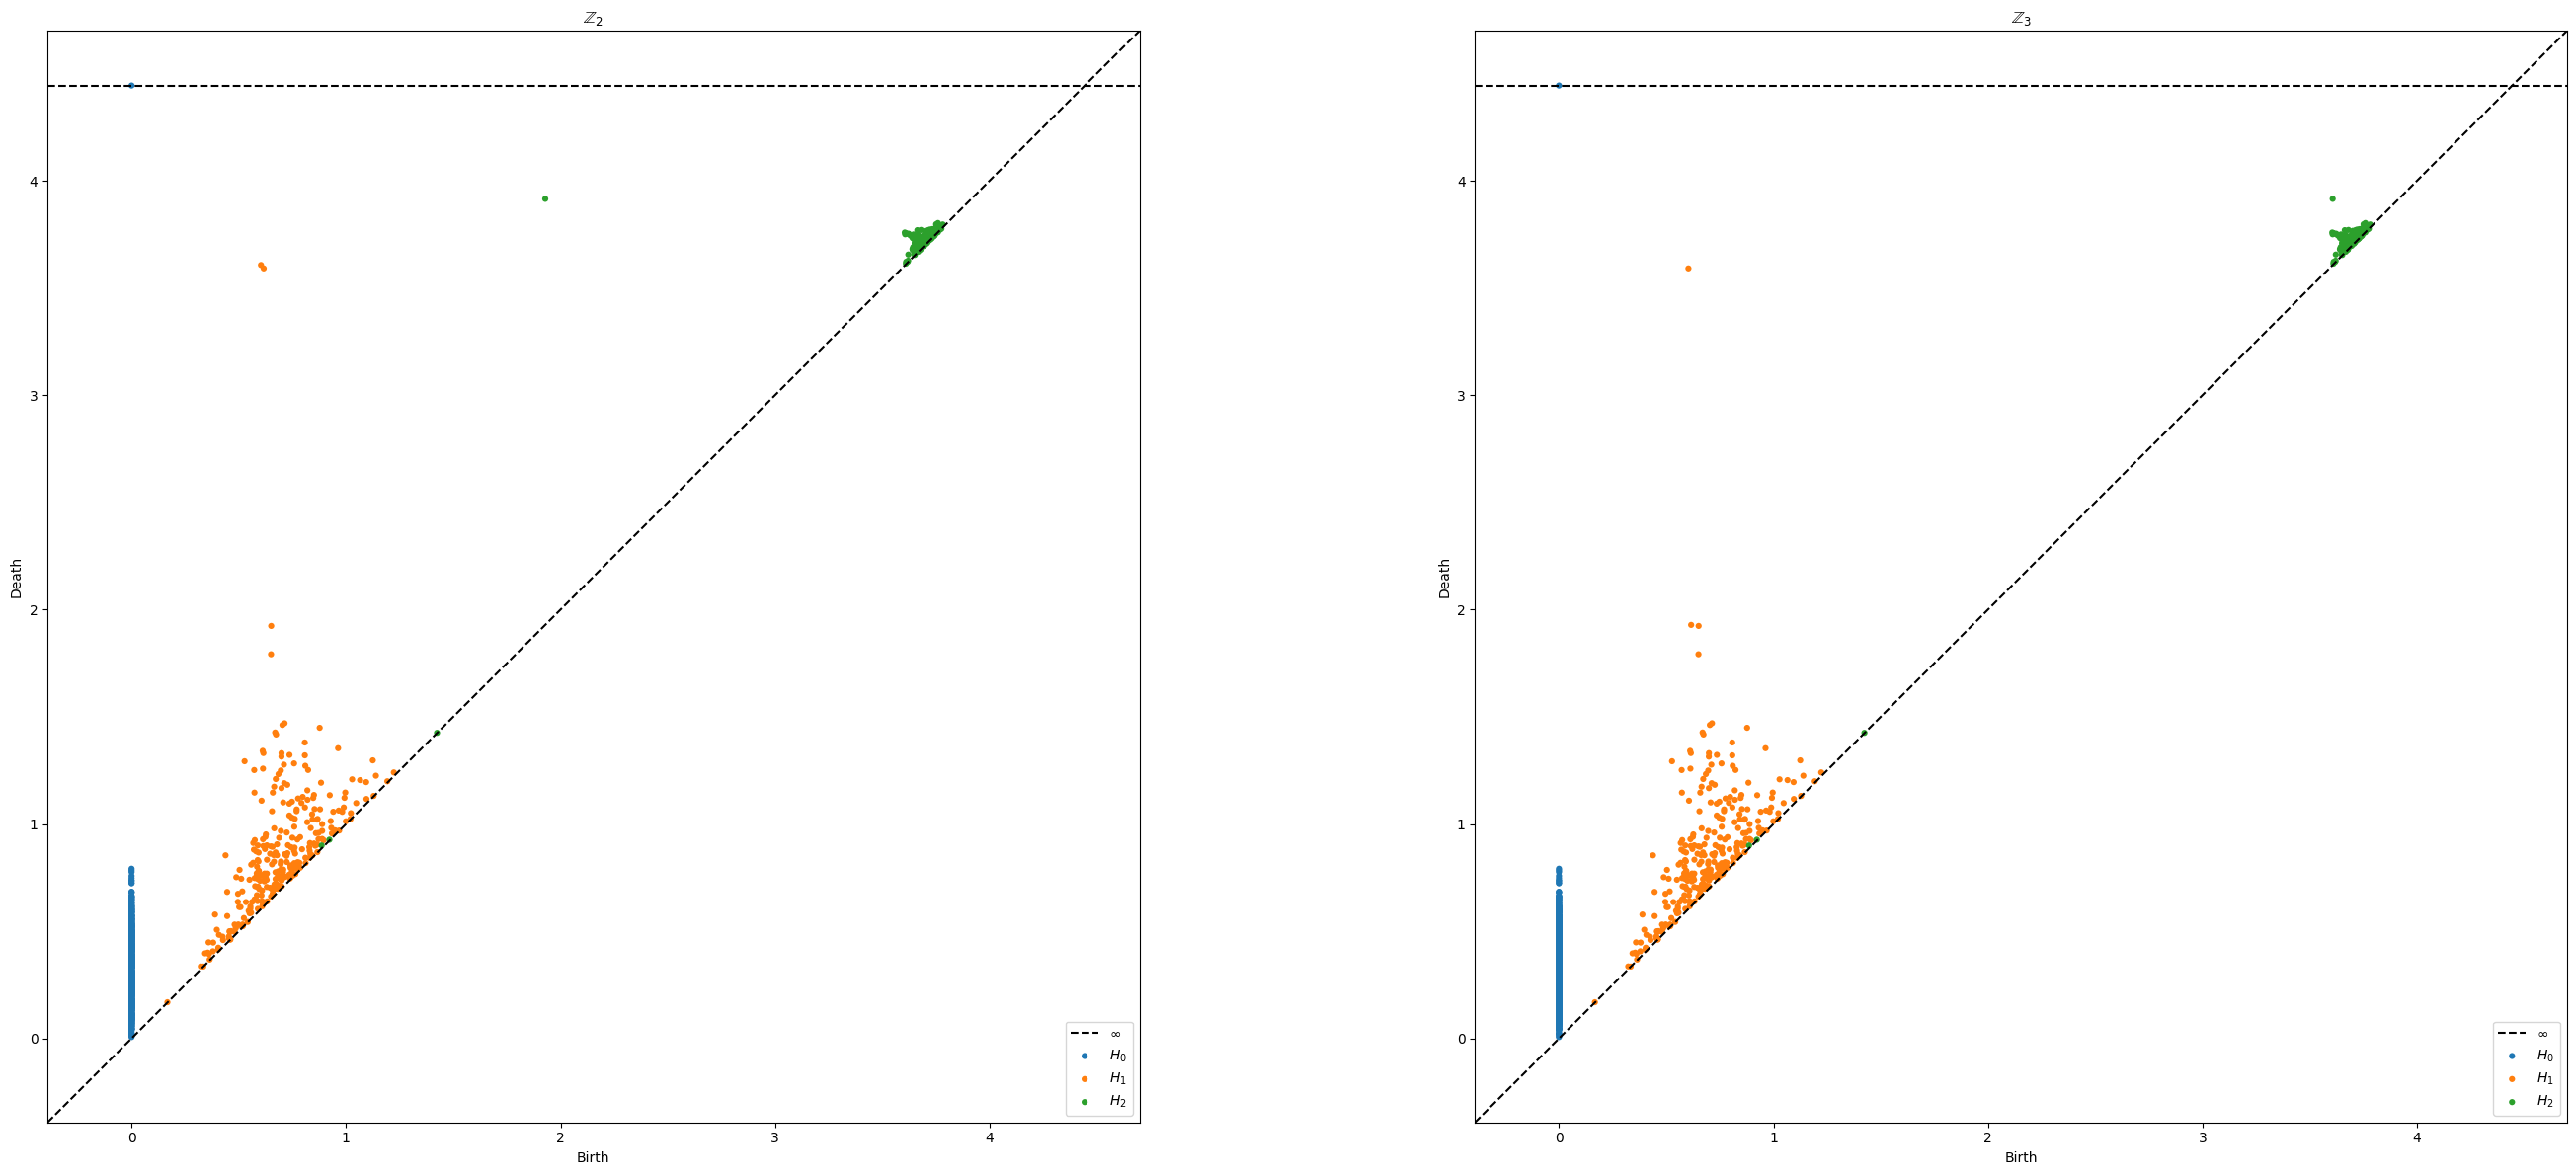

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(30, 12))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [ ]:
lifespan_of_1cycles = sorted([d - b for b,d in diagrams2[1]], reverse=True)
lifespan_of_1cycles[:10]

[np.float64(2.978184700012207),
 np.float64(2.960745096206665),
 np.float64(1.1651133298873901),
 np.float64(0.852570116519928),
 np.float64(0.8524386286735535),
 np.float64(0.7718299627304077),
 np.float64(0.7373191714286804),
 np.float64(0.6849209666252136),
 np.float64(0.6805980801582336),
 np.float64(0.6783149242401123)]

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


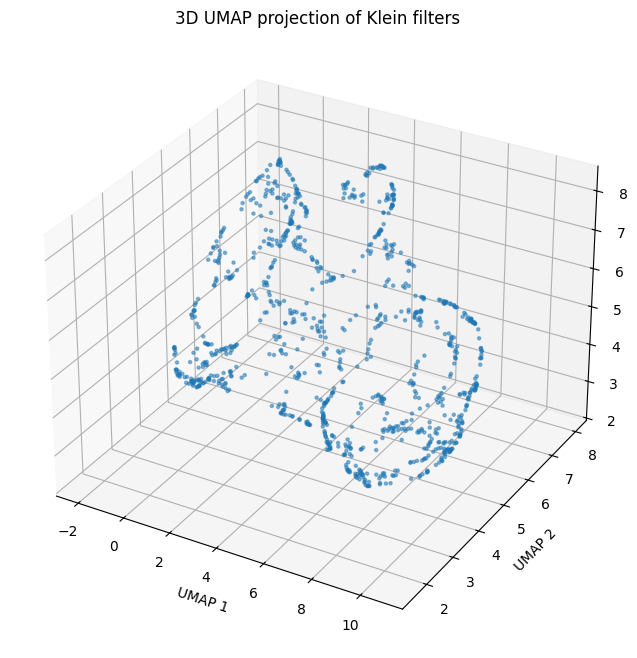

CPU times: user 2.87 s, sys: 138 ms, total: 3.01 s
Wall time: 3.08 s


In [ ]:
%%time

reducer = umap.UMAP(n_components=3, random_state=28)
reducer.fit(X)
klein_embedding = reducer.transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(klein_embedding[:, 0], klein_embedding[:, 1], klein_embedding[:, 2], s=5, alpha=0.5)
ax.set_title('3D UMAP projection of Klein filters')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

#### Additional: $\theta_1$ runs up to $2\pi$
We really should just get the same

In [ ]:
n_angles = 1_000

th1s = np.random.uniform(0, 2 * np.pi, n_angles)
th2s = np.random.uniform(0, 2 * np.pi, n_angles)

In [ ]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(1000, 9)

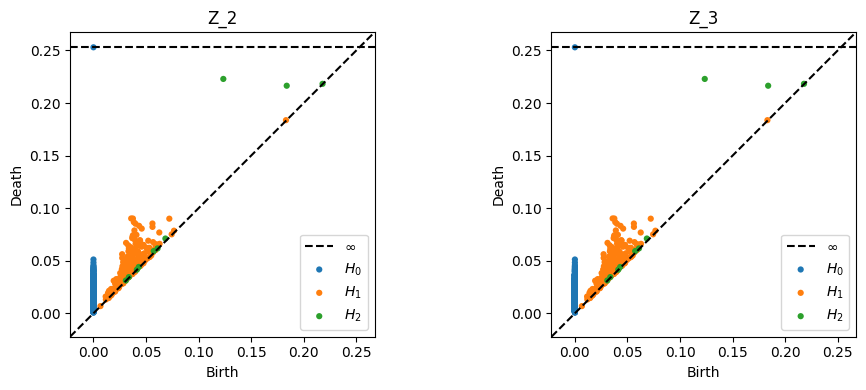

In [ ]:
diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

## Comparing to DWP-data


In [ ]:
y = np.load("/kaggle/input/deep-weight-prior-data/conv5x5/test.npy")[:,0,:,:] # np.load('dwp-data/conv5x5/test.npy')[:,0,:,:]

y /= np.linalg.norm(y, axis = (1,2))[np.newaxis,np.newaxis].T
y = y.reshape(y.shape[0], -1)
size = int(np.sqrt(y.shape[1]))
y.shape

(20448, 25)

In [ ]:
thetas = Sobol(d=2).random(20448)

thetas *= 2*np.pi

xs = np.linspace(-1, 1, size)
ys = np.linspace(-1, 1, size)
xv, yv = np.meshgrid(xs, ys)

klein_matrices = []

for i in range(2048):
    filter_ = generate_klein_filter_matrix(thetas[i,0],thetas[i,1], size=size, midpoint=False)
    klein_matrices.append(filter_.flatten())
    
klein_matrices = np.array(klein_matrices)

klein_matrices /= np.linalg.norm(klein_matrices, axis = (1))[np.newaxis].T

/usr/local/lib/python3.11/dist-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


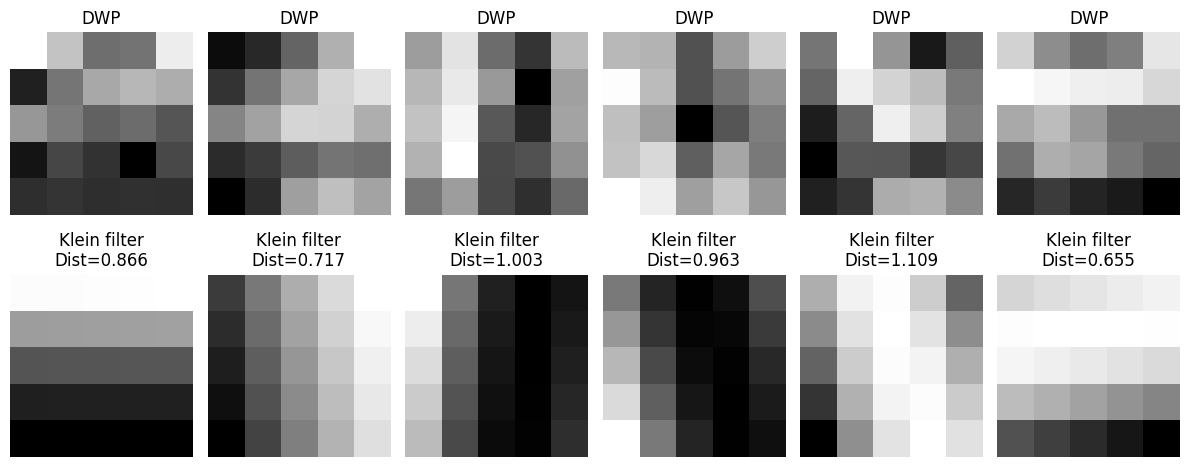

In [ ]:
n_examples = 6
ds = pairwise_distances(y, klein_matrices)
indices = np.random.choice(20448, n_examples, replace=False)

fig, axes = plt.subplots(2, n_examples, figsize=(2 * n_examples, 5))

for col, i in enumerate(indices):
    # DWP filter
    axes[0, col].imshow(y[i, :].reshape((size, size)), cmap='gray')
    axes[0, col].set_title('DWP')
    axes[0, col].axis('off')
    
    # Closest Klein filter
    j_nearest = np.argmin(ds[i, :])
    axes[1, col].imshow(klein_matrices[j_nearest].reshape((size, size)), cmap='gray')
    dist = ds[i, j_nearest]
    axes[1, col].set_title(f'Klein filter\nDist={dist:.3f}')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'klein_embedding' is not defined

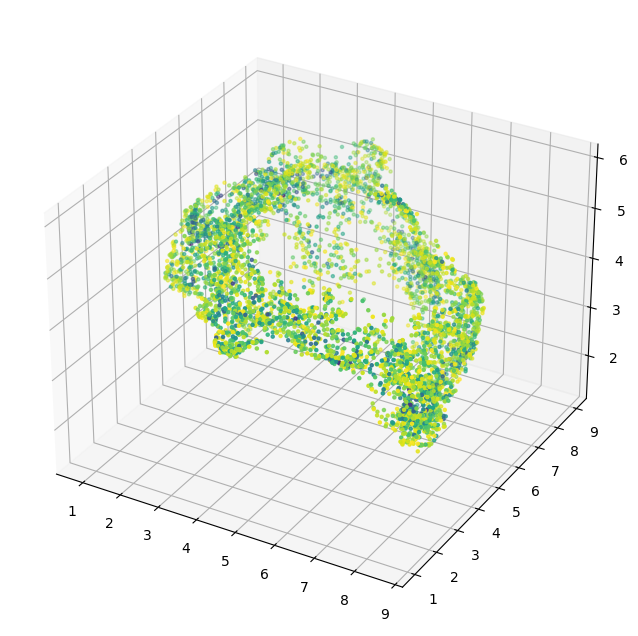

In [ ]:
%%time

threshold = 0.75  # Set your desired threshold here

ds = pairwise_distances(y, klein_matrices)
min_distances = np.min(ds, axis=1)

# Mask for points below the threshold
mask = min_distances <= threshold
y_filtered = y[mask]
min_distances_filtered = min_distances[mask]

# Filtered embeddings and distances
reducer = umap.UMAP(n_components=3, random_state=28)
embedding_filtered = reducer.fit_transform(y_filtered)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    embedding_filtered[:, 0],
    embedding_filtered[:, 1],
    embedding_filtered[:, 2],
    c=min_distances_filtered,
    cmap='viridis',
    s=5
)

ax.scatter(klein_embedding[:, 0], klein_embedding[:, 1], klein_embedding[:, 2], s=5, alpha=0.5)

fig.colorbar(sc, label='Distance to closest Klein filter')
ax.set_title(f'3D UMAP of DWP filters (distance ≤ {threshold})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

In [ ]:
y_filtered_ph_computation = y_filtered[::10]
y_filtered_ph_computation.shape

(507, 25)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value 

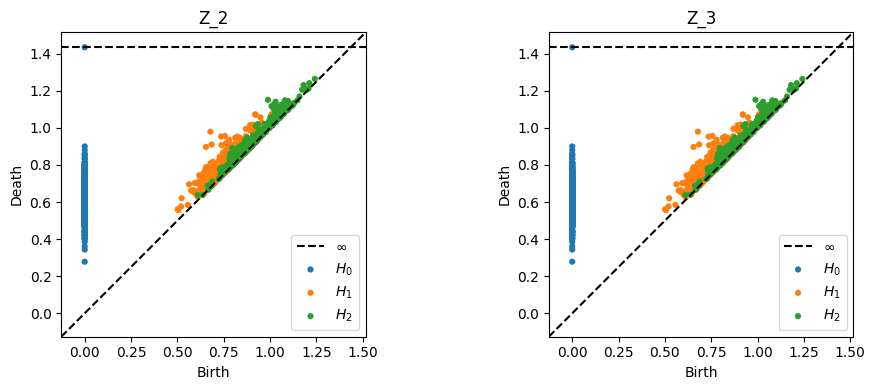

CPU times: user 13.1 s, sys: 460 ms, total: 13.6 s
Wall time: 13.6 s


In [ ]:
%%time

diagrams2 = ripser(y_filtered_ph_computation, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(y_filtered_ph_computation, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()